## Regridding with esmvalcore API

[doc](https://docs.esmvaltool.org/projects/ESMValCore/en/latest/api/esmvalcore.preprocessor.html#esmvalcore.preprocessor.regrid)

- reasons, comparison, Omon, processing based on lon lat
- different schemes

In [1]:
from esmvalcore.dataset import Dataset
from esmvalcore.preprocessor import regrid

from esmvalcore.preprocessor import (climate_statistics,
    convert_units,
)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [2]:
ESM15 = Dataset(
    short_name='ts', project='CMIP6', mip="Amon", exp="historical",
    ensemble="r1i1p1f1", timerange="20000101/20140101",
    dataset="ACCESS-ESM1-5", grid="gn"
)
CM2_o = Dataset(
    short_name='tos', project='CMIP6', mip="Omon", exp="historical",
    ensemble="r1i1p1f1", timerange="20000101/20140101",
    dataset="ACCESS-CM2", grid="gn"
)

obs_datasets = {
"HadISST": 
    Dataset(
    short_name='ts', dataset='HadISST', mip="Amon",
    project='OBS', type='reanaly', tier=2),
}

### Ancillary data

In [3]:
#cell area
ESM15.add_supplementary(short_name="areacella", mip="fx") 
CM2_o.add_supplementary(short_name="areacello", mip="Ofx")

In [4]:
model_datasets = {'ESM1-5_ts': ESM15.load(), 'CM2_tos':CM2_o.load()}
obs_datasets = {name: dataset.load() for name, dataset in obs_datasets.items()}

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/ESMValCore/pull/2747 for details). To silent this warning and ignore deprecated extra facets, set the environment variable ESMVALTOOL_USE_NEW_EXTRA_FACETS_CONFIG=1.
  warn_if_old_extra_facets_exist()
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/esmvalcore/config/_config.py:59: ESMValCoreDeprecationWarning: Usage of extra facets located in ~/.esmvaltool/extra_facets has been deprecated in ESMValCore version 2.13.0 and is scheduled for removal in version 2.15.0. Please use the configuration option `extra_facets` instead (see https://github.com/ESMValGroup/

### collapse time,  for 2d data

In [5]:
data_2d = {}

for name, cube in {**model_datasets, **obs_datasets}.items():
    # inspect summaries
    print(name, cube.summary(shorten=True))
    # time mean
    cube = climate_statistics(cube, period='full', operator='mean')
    # convert units
    data_2d[name] = convert_units(cube, 'degC')

ESM1-5_ts surface_temperature / (K)           (time: 168; latitude: 145; longitude: 192)
CM2_tos sea_surface_temperature / (degC)    (time: 168; cell index along second dimension: 300; cell index along first dimension: 360)
HadISST surface_temperature / (K)           (time: 1824; latitude: 180; longitude: 360)


In [6]:
import iris.plot as iplt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [36]:
# figure plot settings

# i = 131
def subplot_cube(cube, i, proj, title):
    ax1 = plt.subplot(i, projection=proj)
    cf1 = iplt.contourf(cube, axes=ax1, levels=np.arange(-5,35,1), extend='both', cmap='RdBu_r')
    ax1.coastlines()
    ax1.set_extent([100, 150, -10, 30], crs=ccrs.PlateCarree())
    gl1 = ax1.gridlines(draw_labels=True, linestyle='--')
    ax1.set_title(title)
    plt.colorbar(cf1, orientation='horizontal')
    

## regridding different schemes

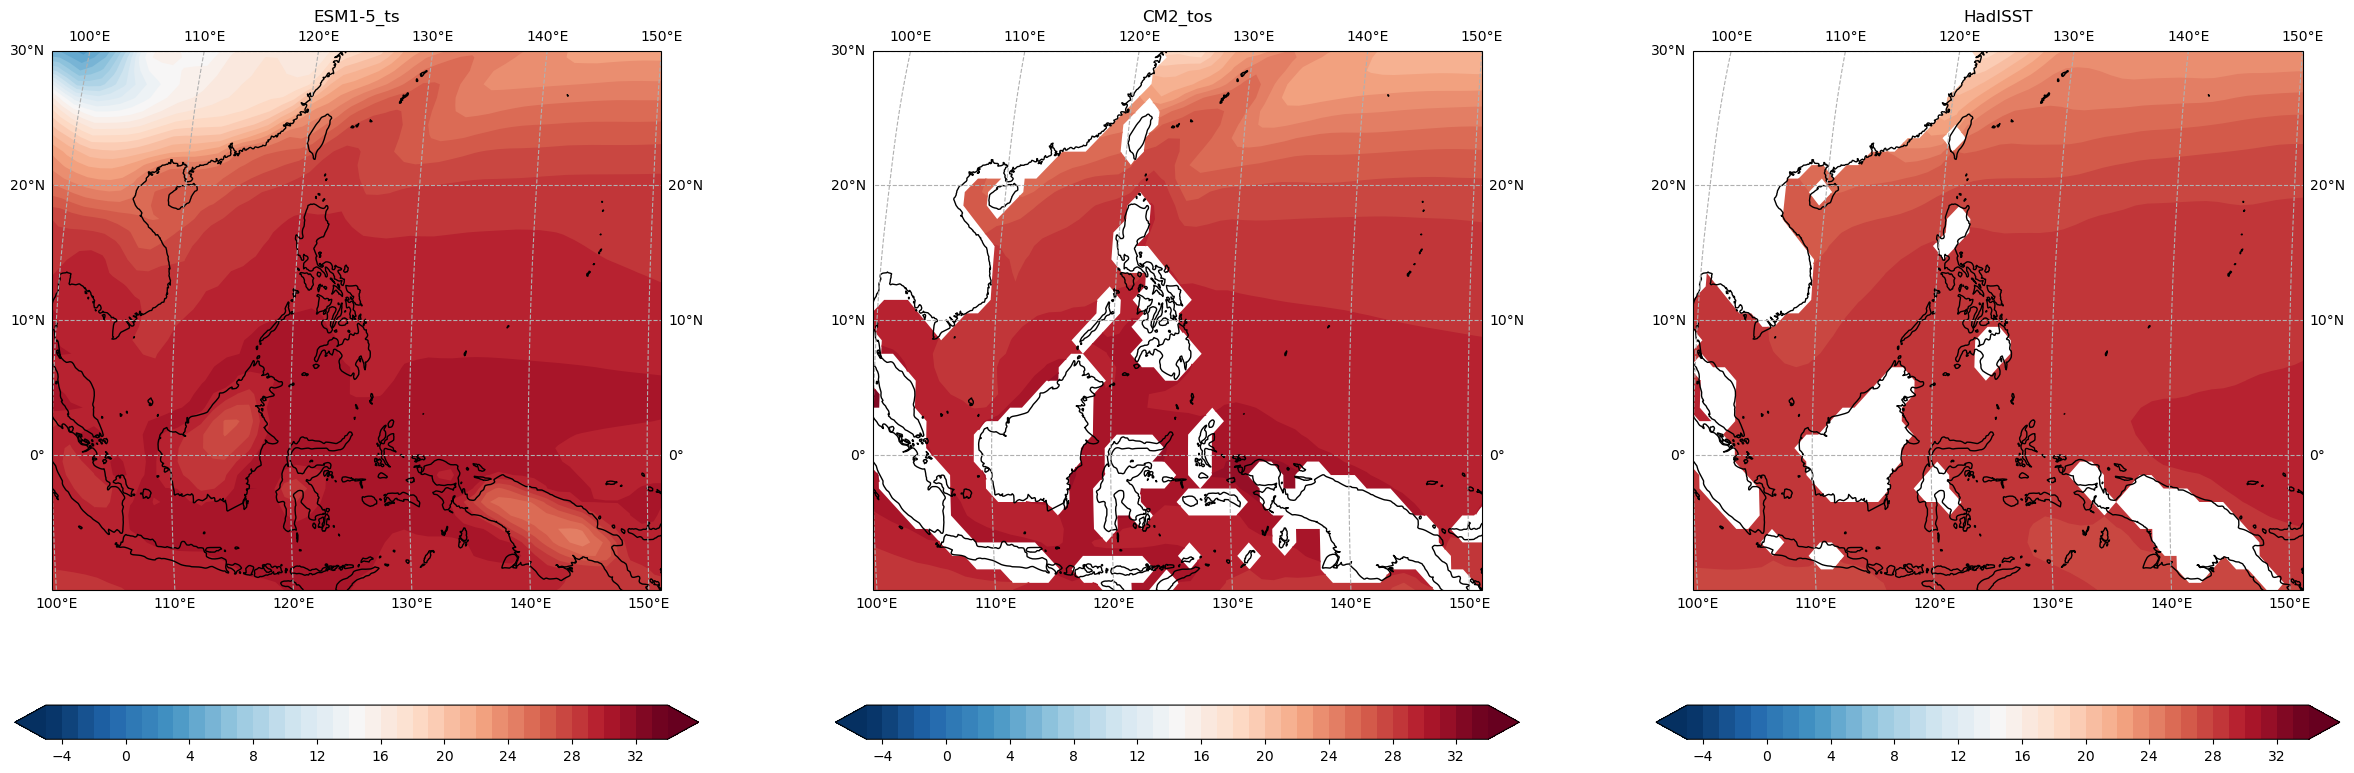

In [37]:
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width
proj = ccrs.cartopy.crs.Robinson(central_longitude=180.0)
i = 131

for name, cube in data_2d.items():
    cube = regrid(cube, target_grid="1x1", scheme="linear")
    # plot maps
    subplot_cube(cube, i, proj, name)
    i+=1


## nearest

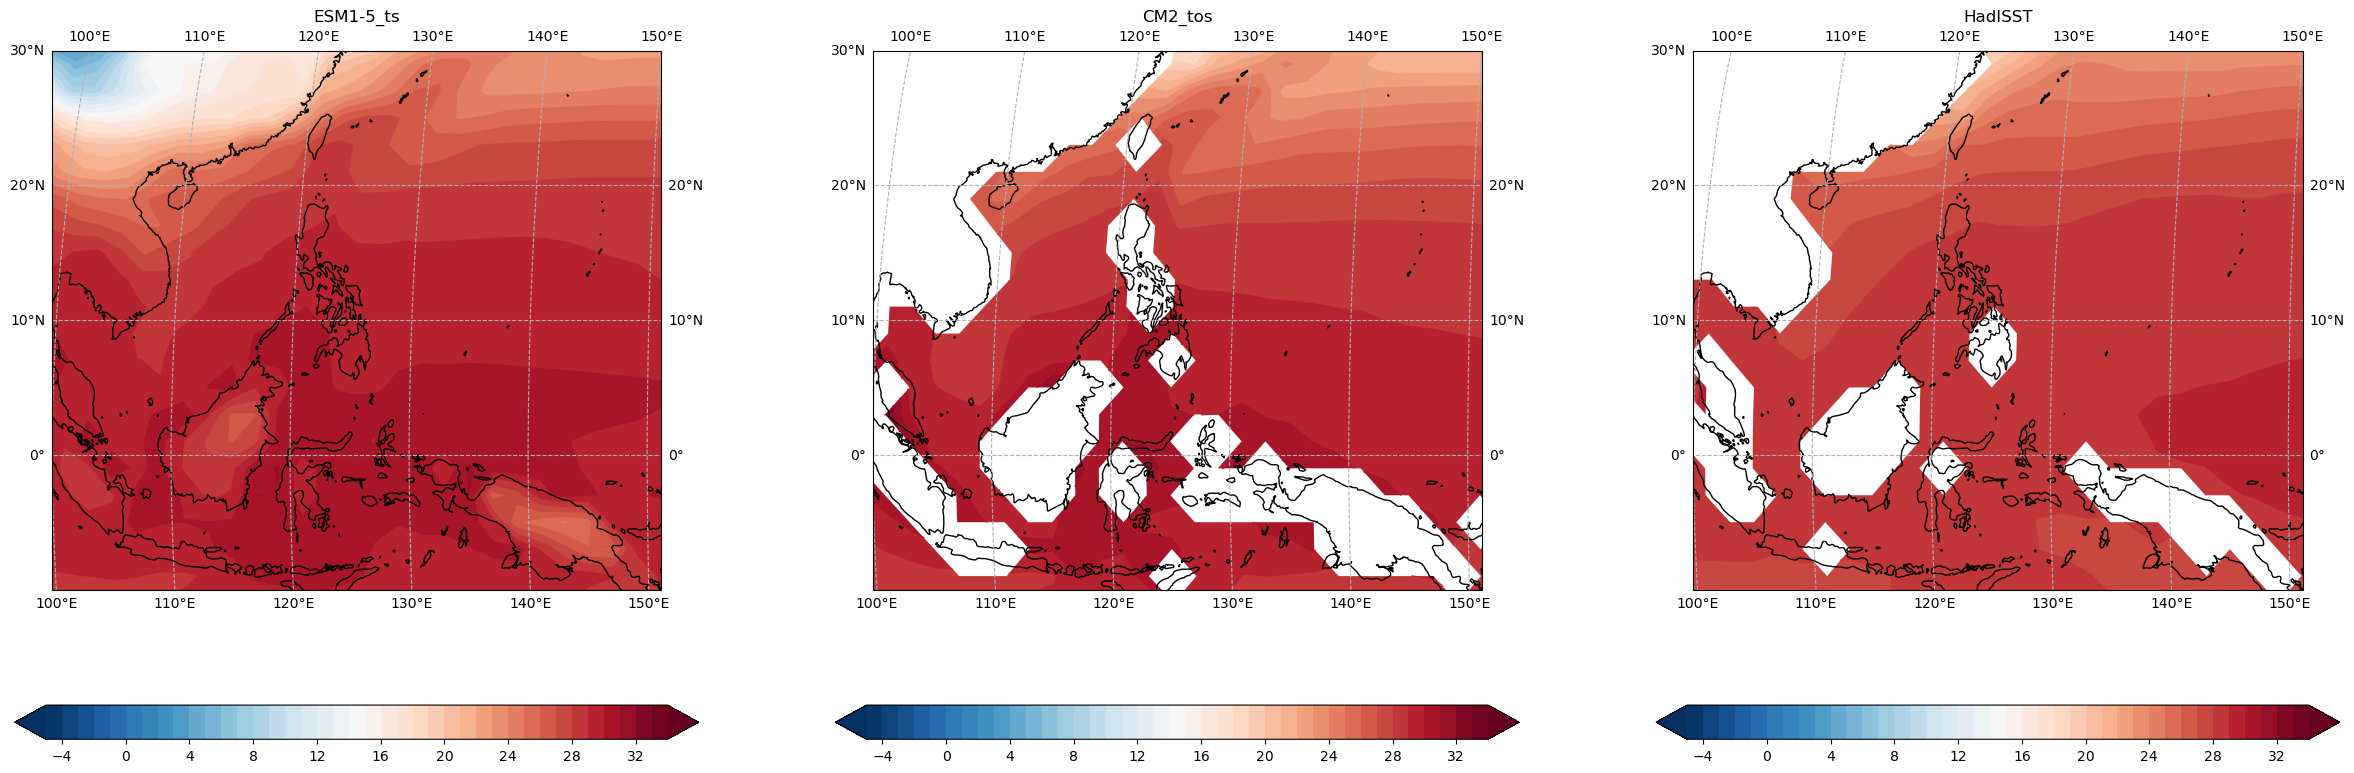

In [38]:
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width
proj = ccrs.cartopy.crs.Robinson(central_longitude=180.0)
i = 131

for name, cube in data_2d.items():
    cube = regrid(cube, target_grid="2x2", scheme="nearest")
    # plot maps
    subplot_cube(cube, i, proj, name)
    i+=1


## target grid - Dataset

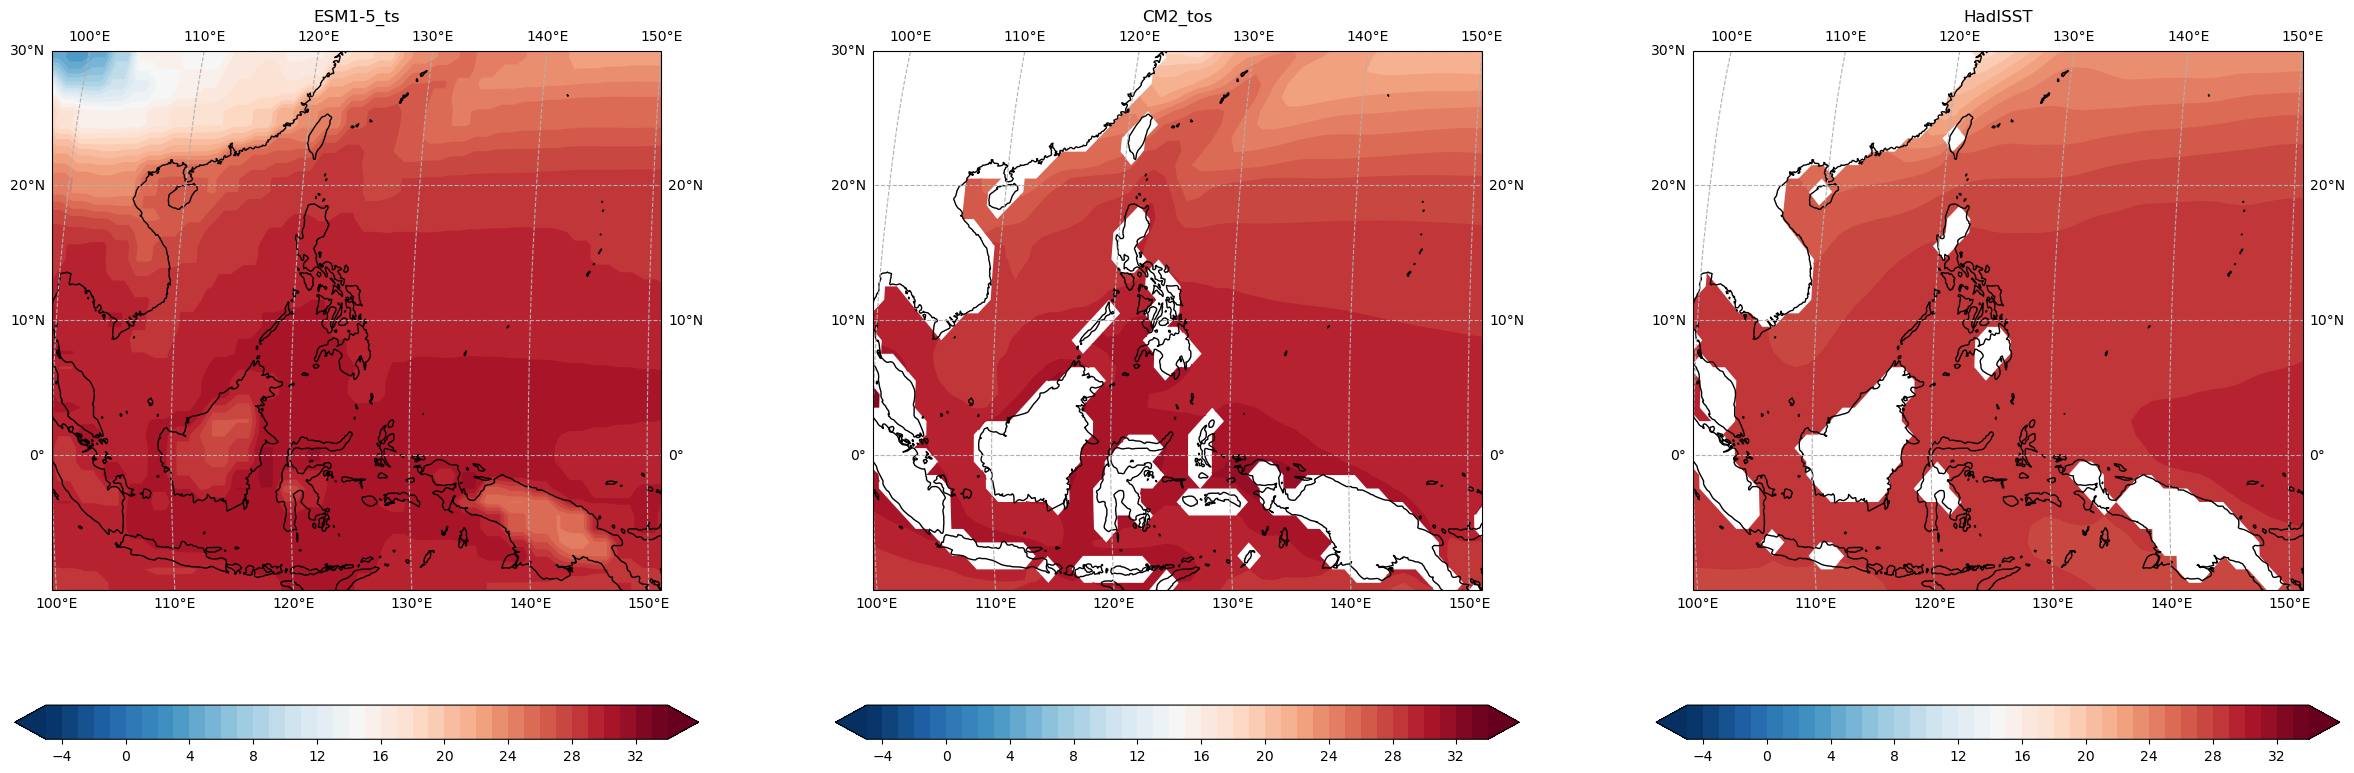

In [39]:
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width
proj = ccrs.cartopy.crs.Robinson(central_longitude=180.0)
i = 131

for name, cube in data_2d.items():
    cube = regrid(cube, target_grid=obs_datasets['HadISST'], scheme="nearest")
    # plot maps
    subplot_cube(cube, i, proj, name)
    i+=1


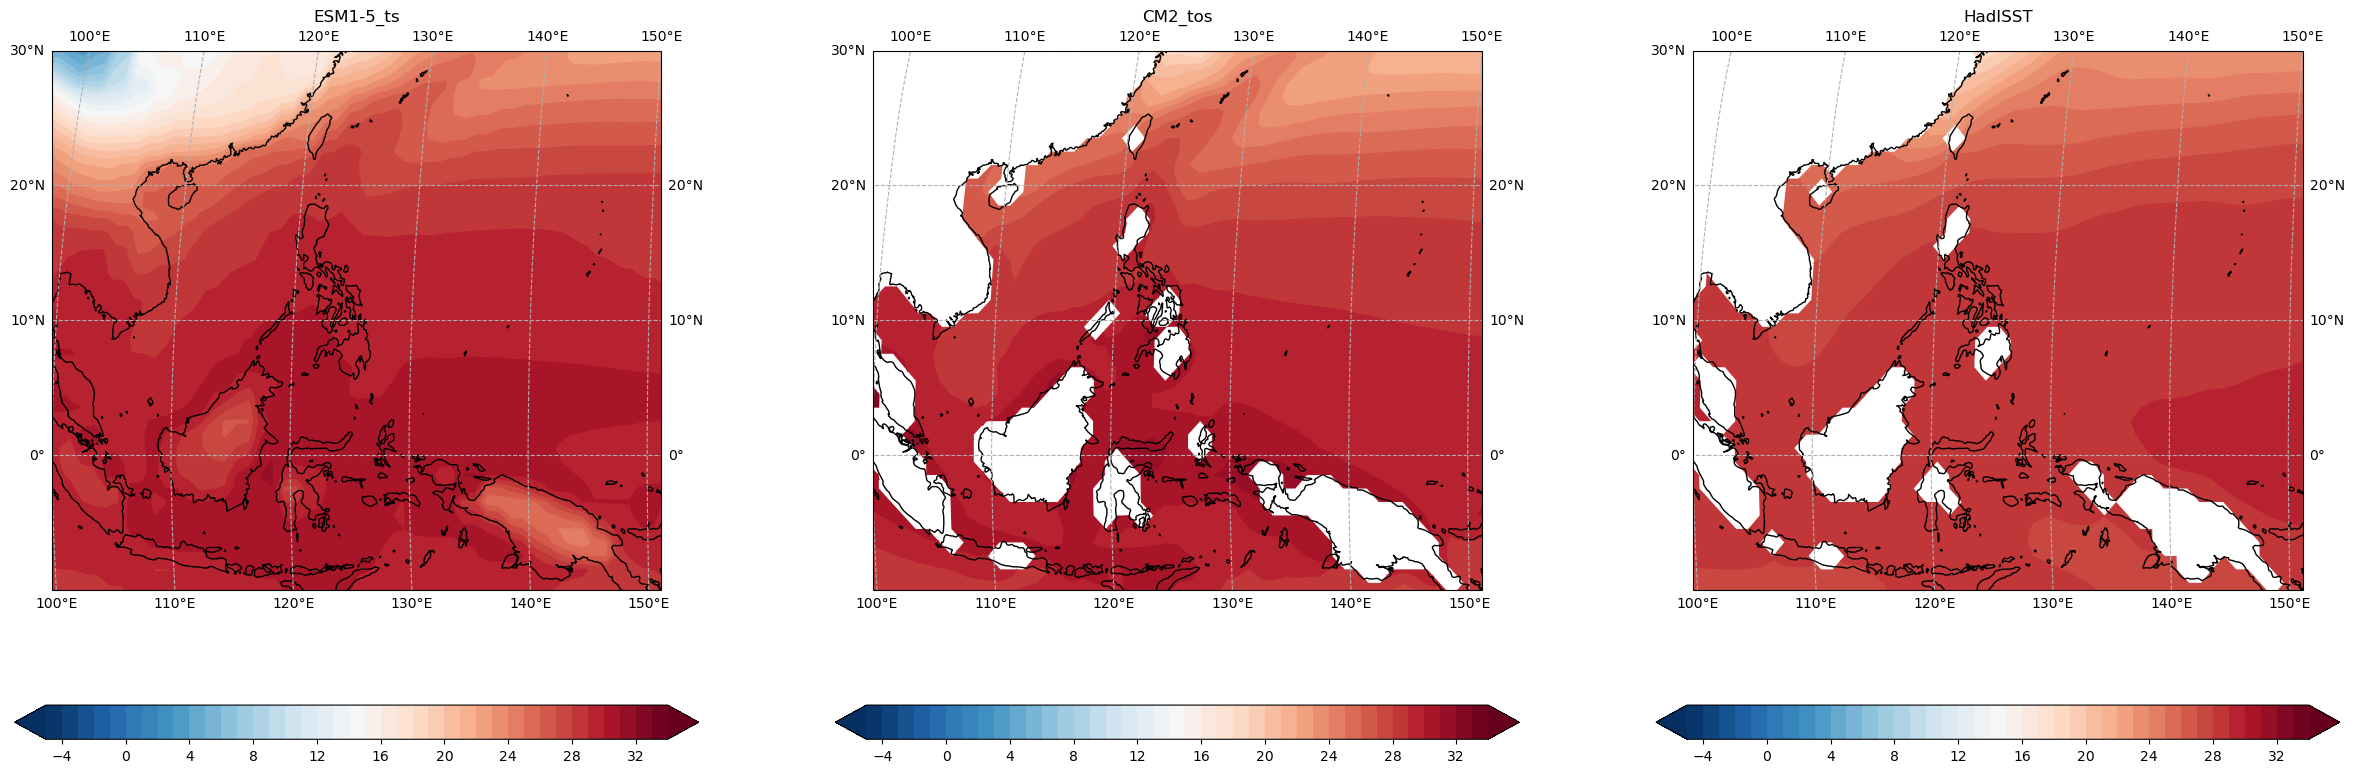

In [40]:
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width
proj = ccrs.cartopy.crs.Robinson(central_longitude=180.0)
i = 131

for name, cube in data_2d.items():
    cube = regrid(cube, target_grid=obs_datasets['HadISST'], scheme="area_weighted")
    # plot maps
    subplot_cube(cube, i, proj, name)
    i+=1


### available regrid schemes
[regrid schemes docs](https://docs.esmvaltool.org/projects/ESMValCore/en/latest/api/esmvalcore.regridding_schemes.html)

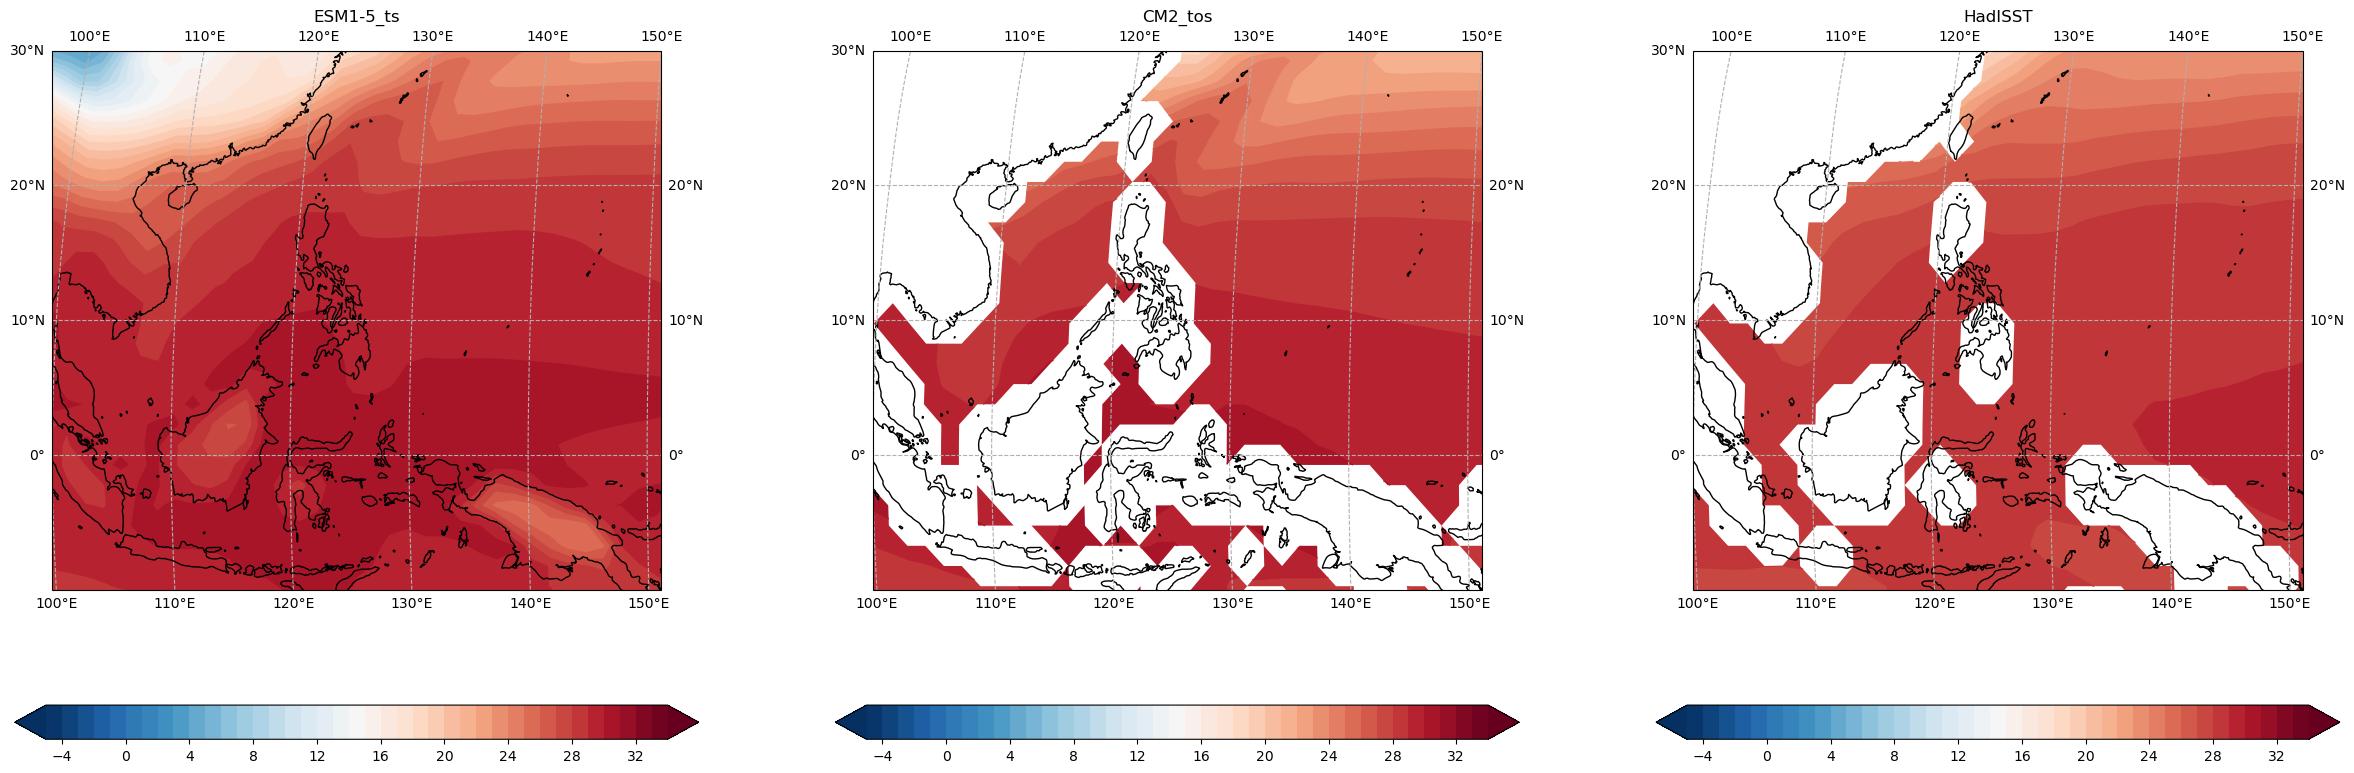

In [41]:
fig = plt.figure(figsize=(30, 10))  # Adjusted for full width
proj = ccrs.cartopy.crs.Robinson(central_longitude=180.0)
i = 131

for name, cube in data_2d.items():
    cube = regrid(cube, target_grid='1.5x1.5', 
                  scheme={'reference':"esmf_regrid.schemes:ESMFAreaWeighted"
                          })
    # plot maps
    subplot_cube(cube, i, proj, name)
    i+=1
